In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
print(df['TotalCharges'].dtype)
print((df['TotalCharges'].str.strip() == '').sum()) 

object
11


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


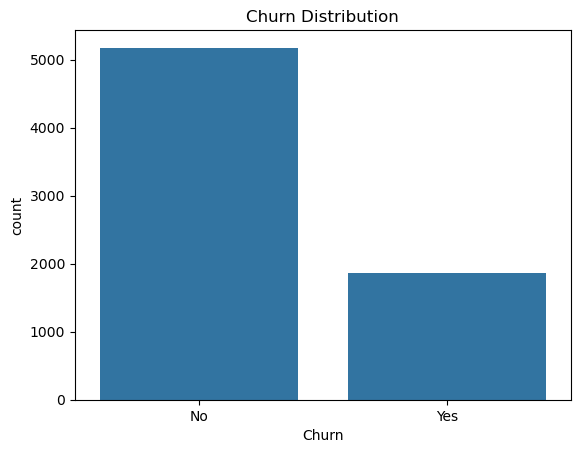

In [6]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

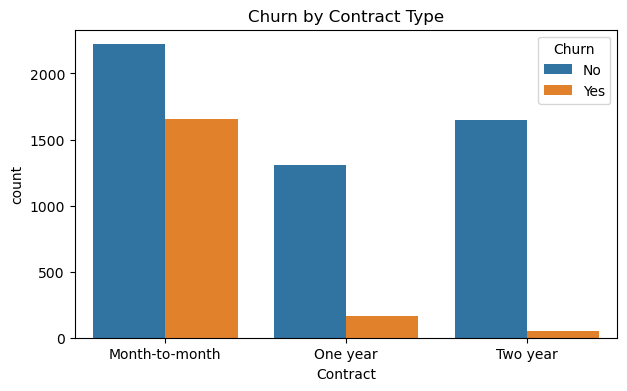

In [7]:
# Cell 8: Churn by contract type
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

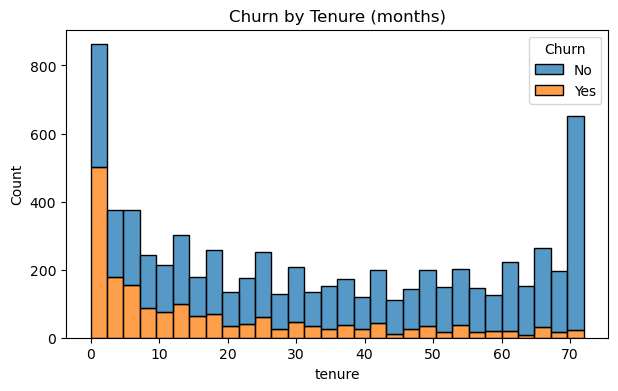

In [8]:
# Cell 9: Churn by tenure
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Tenure (months)')
plt.show()

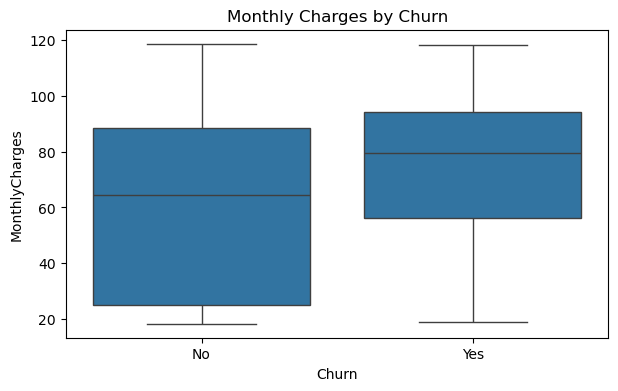

In [9]:
# Cell 10: Churn by monthly charges
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

In [10]:
# Cell 11: Fix TotalCharges
df['TotalCharges'] = df['TotalCharges'].str.strip()          # remove stray spaces
df['TotalCharges'] = df['TotalCharges'].replace('', np.nan)   # turn blanks into real NaN
df['TotalCharges'] = df['TotalCharges'].astype(float)         # convert text to numeric

print(df['TotalCharges'].isnull().sum())  # confirm how many are now missing

11


In [11]:
# Cell 12: Handle the missing rows
# Only a handful of rows (~11) — safe to drop rather than impute
df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 21)


In [12]:
# Cell 13: Drop customerID (it's just an identifier, no predictive value)
df = df.drop(columns=['customerID'])

In [13]:
# Cell 14: Convert Churn (Yes/No) to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
# Cell 15: Split into X (features) and y (target)
X = df.drop(columns=['Churn'])
y = df['Churn']

In [15]:
# Cell 16: Separate column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [16]:
# Cell 17: One-hot encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [17]:
# Cell 18: Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [18]:
# Cell 19: Scale numeric columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [19]:
# Cell 20: Save scaler and training columns
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

In [20]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [21]:
# Cell 21: Check class weight approach
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(0): np.float64(0.6809927360774818), np.int64(1): np.float64(1.8812709030100334)}


In [22]:
# Cell 22: Apply SMOTE to training data only
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {0: 4130, 1: 4130}


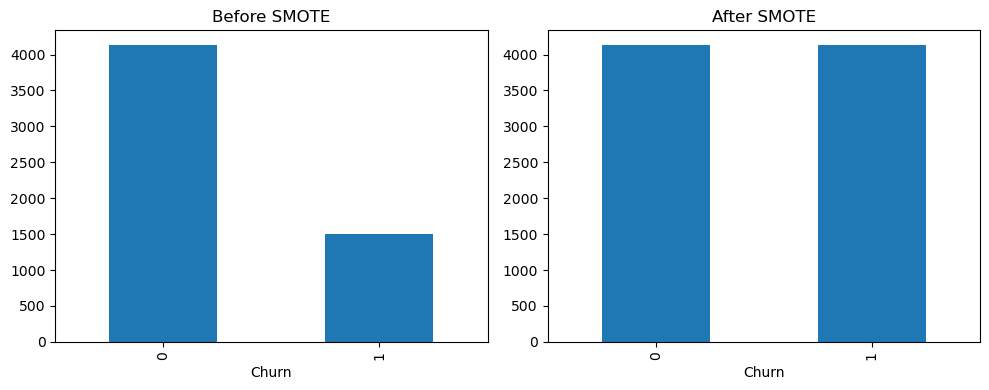

In [23]:
# Cell 23: Compare class distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))
y_train.value_counts().plot(kind='bar', ax=axes[0], title='Before SMOTE')
y_train_smote.value_counts().plot(kind='bar', ax=axes[1], title='After SMOTE')
plt.tight_layout()
plt.show()

In [24]:
# Cell 24: Logistic Regression with class weights
from sklearn.linear_model import LogisticRegression

log_reg_cw = LogisticRegression(class_weight=class_weight_dict, max_iter=1000, random_state=42)
log_reg_cw.fit(X_train, y_train)

y_pred_cw = log_reg_cw.predict(X_test)

In [25]:
# Cell 25: Logistic Regression with SMOTE
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_reg_smote.predict(X_test)

In [26]:
# Cell 26: Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Class Weight Version ===")
print(classification_report(y_test, y_pred_cw))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_cw.predict_proba(X_test)[:,1]))

print("\n=== SMOTE Version ===")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_smote.predict_proba(X_test)[:,1]))

=== Class Weight Version ===
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8353130128228357

=== SMOTE Version ===
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.72      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.78      0.74      0.75      1407

ROC-AUC: 0.8217240165449264


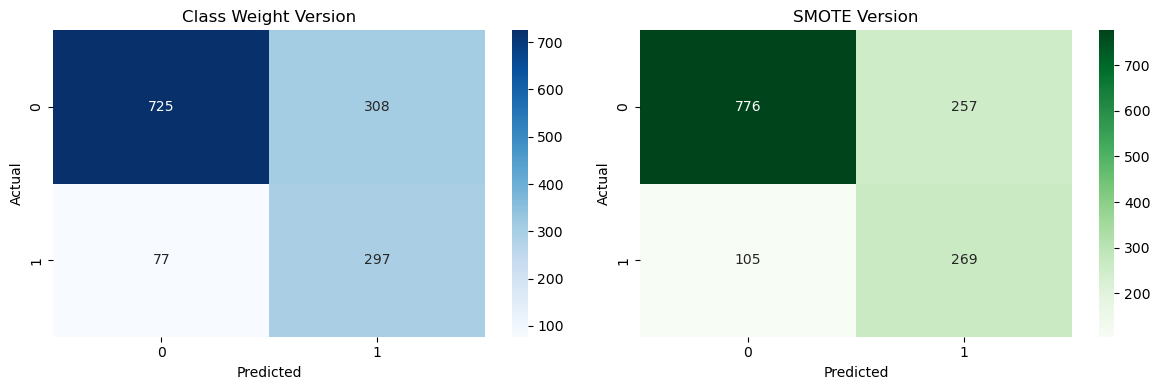

In [27]:
# Cell 27: Confusion matrix comparison
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))

cm_cw = confusion_matrix(y_test, y_pred_cw)
sns.heatmap(cm_cw, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Class Weight Version')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('SMOTE Version')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [28]:
# Cell 28: Save best baseline model
import joblib
joblib.dump(log_reg_smote, 'baseline_model.pkl')  # swap to log_reg_cw if that one wins

['baseline_model.pkl']

In [29]:
# Cell 29: Random Forest with class weights
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight=class_weight_dict, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [32]:
# Cell 30: XGBoost with scale_pos_weight (its version of class weighting)


from xgboost import XGBClassifier

# scale_pos_weight = ratio of negative to positive class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [33]:
# Cell 31: Compare all models
from sklearn.metrics import classification_report, roc_auc_score

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8166119655641892

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1033
           1       0.51      0.66      0.58       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.74      0.75      1407

ROC-AUC: 0.8098990014029022


In [34]:
# Cell 32: Hyperparameter tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',   # optimize for catching churners
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [35]:
# Cell 33: Evaluate tuned XGBoost
y_pred_best = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.60       374

    accuracy                           0.71      1407
   macro avg       0.69      0.75      0.69      1407
weighted avg       0.80      0.71      0.73      1407

ROC-AUC: 0.8387490875959642


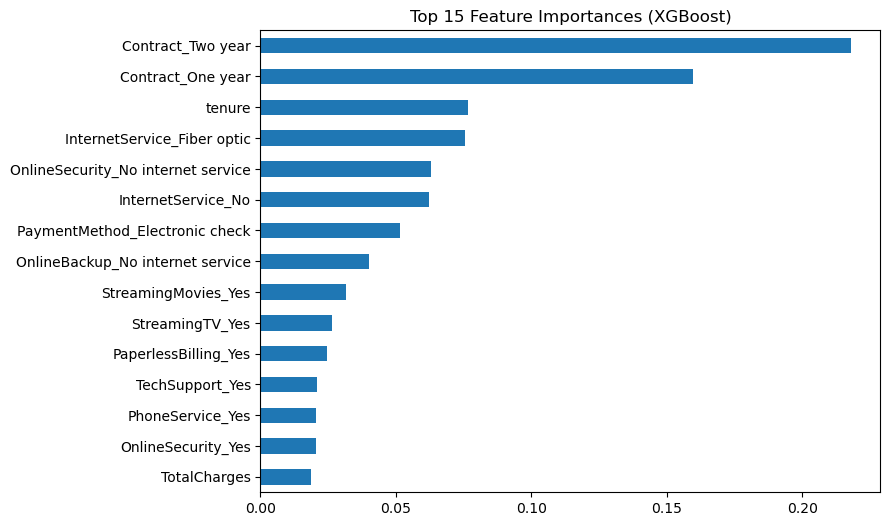

In [36]:
# Cell 34: Feature importance plot
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

In [37]:
# Cell 35: Save final model
import joblib
joblib.dump(best_xgb, 'final_model.pkl')

['final_model.pkl']

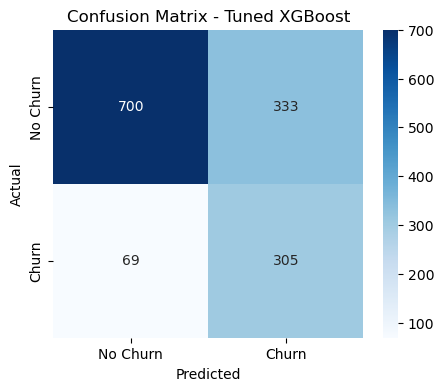

In [38]:
# Cell 36: Confusion matrix for final model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

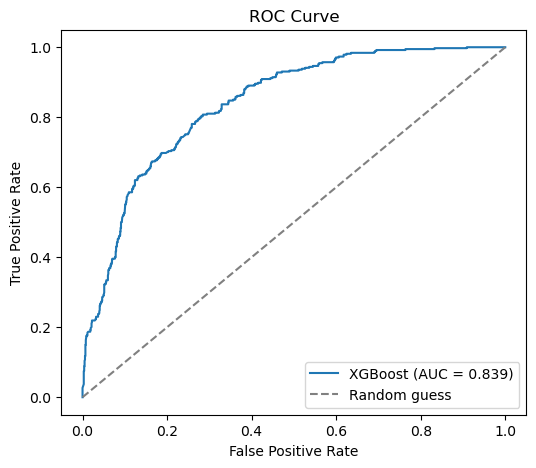

In [39]:
# Cell 37: ROC curve
from sklearn.metrics import roc_curve, auc

y_proba_best = best_xgb.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

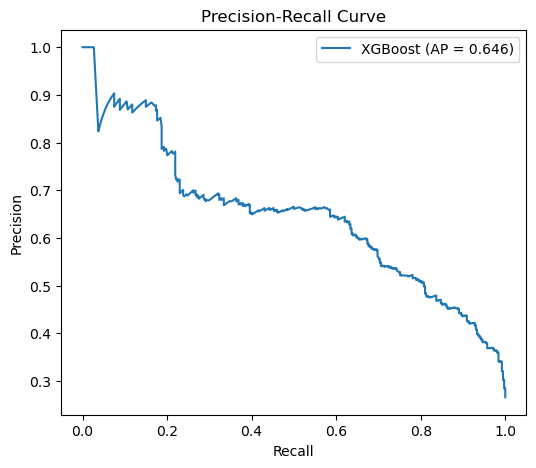

In [40]:
# Cell 38: Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_best)
avg_precision = average_precision_score(y_test, y_proba_best)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'XGBoost (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [41]:
# Cell 39: Try a lower threshold
custom_threshold = 0.35
y_pred_custom = (y_proba_best >= custom_threshold).astype(int)

from sklearn.metrics import classification_report
print(f"Threshold = {custom_threshold}")
print(classification_report(y_test, y_pred_custom))

Threshold = 0.35
              precision    recall  f1-score   support

           0       0.95      0.53      0.68      1033
           1       0.42      0.93      0.57       374

    accuracy                           0.63      1407
   macro avg       0.69      0.73      0.63      1407
weighted avg       0.81      0.63      0.65      1407



In [42]:
# Cell 40: Summary table of all models
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Tuned XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best)
    ],
    'Precision': [
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best)
    ],
    'F1': [
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.742715   0.511407  0.719251  0.597778
1        Random Forest  0.786780   0.626712  0.489305  0.549550
2              XGBoost  0.742004   0.511387  0.660428  0.576429
3        Tuned XGBoost  0.714286   0.478056  0.815508  0.602767


In [44]:
# Cell 41: Create SHAP explainer for the tuned XGBoost model
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

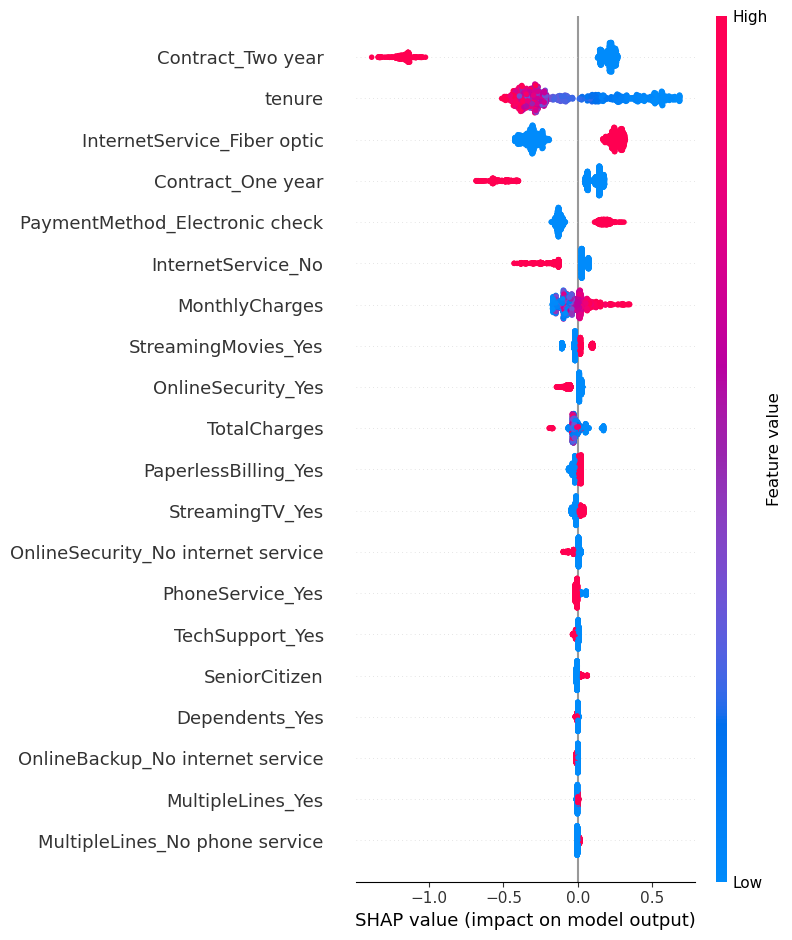

In [45]:
# Cell 42: SHAP summary plot (global view)
shap.summary_plot(shap_values, X_test)

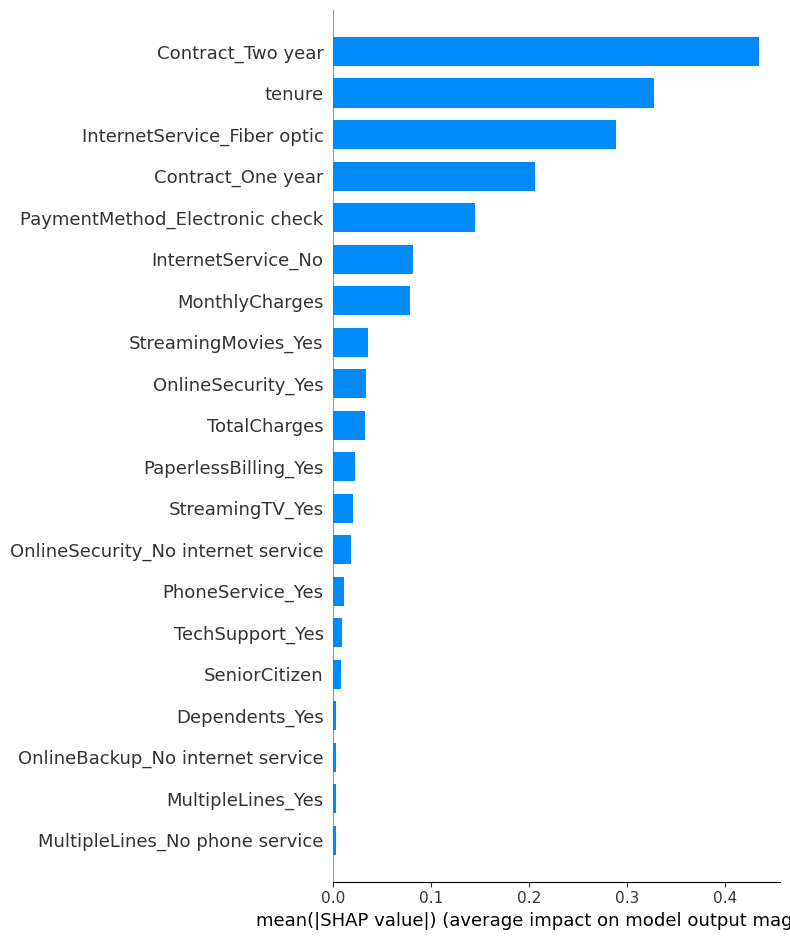

In [46]:
# Cell 43: SHAP bar plot (average impact per feature)
shap.summary_plot(shap_values, X_test, plot_type='bar')

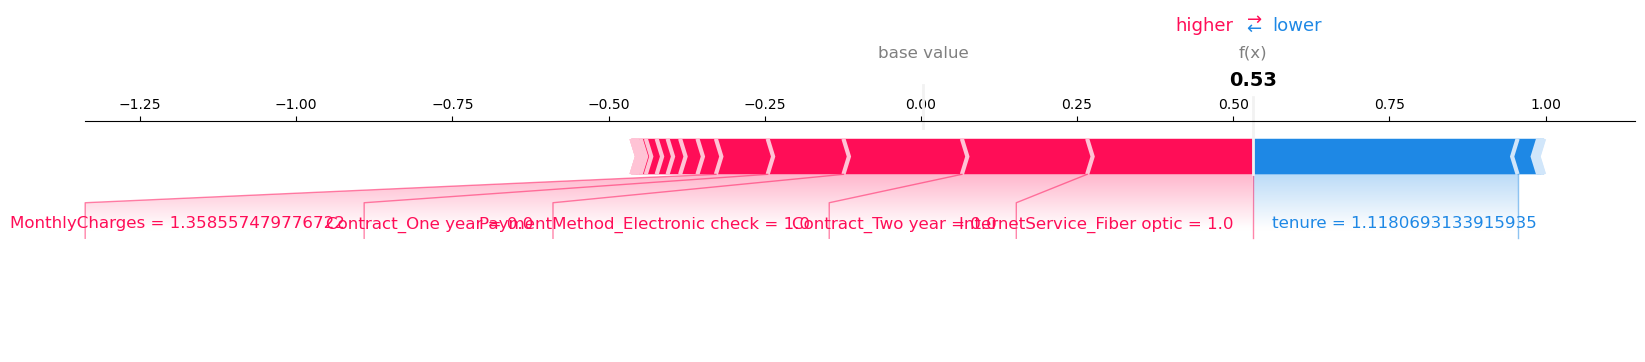

In [47]:
# Cell 44: Explain a single customer's prediction
idx = 5  # pick any row index from X_test

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

In [48]:
# Cell 45: Save plots as images
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.close()

shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True, show=False)
plt.savefig('shap_force_example.png', bbox_inches='tight', dpi=150)
plt.close()

In [49]:
# Cell 46: Save explainer
import joblib
joblib.dump(explainer, 'shap_explainer.pkl')

['shap_explainer.pkl']

In [50]:
# Cell 47: Verify files exist
import os

required_files = ['final_model.pkl', 'scaler.pkl', 'model_columns.pkl', 'shap_explainer.pkl']
for f in required_files:
    print(f, "✅ exists" if os.path.exists(f) else "❌ MISSING")

final_model.pkl ✅ exists
scaler.pkl ✅ exists
model_columns.pkl ✅ exists
shap_explainer.pkl ✅ exists


In [51]:
# Cell 48: Preprocessing function for new/raw input
import pandas as pd
import joblib

scaler = joblib.load('scaler.pkl')
model_columns = joblib.load('model_columns.pkl')

def preprocess_input(raw_dict):
    """
    raw_dict: a dictionary of raw feature values, e.g.
    {'tenure': 12, 'MonthlyCharges': 70.5, 'Contract': 'One year', ...}
    Returns a properly encoded, scaled, column-aligned DataFrame ready for prediction.
    """
    df_input = pd.DataFrame([raw_dict])

    # One-hot encode same way as training
    categorical_cols = df_input.select_dtypes(include='object').columns.tolist()
    df_input = pd.get_dummies(df_input, columns=categorical_cols, drop_first=True)

    # Align columns: add any missing dummy columns as 0, drop extras, keep training order
    df_input = df_input.reindex(columns=model_columns, fill_value=0)

    # Scale numeric columns (only ones the scaler was fit on)
    numerical_cols = scaler.feature_names_in_.tolist()
    df_input[numerical_cols] = scaler.transform(df_input[numerical_cols])

    return df_input

In [52]:
# Cell 49: Test with one example input
final_model = joblib.load('final_model.pkl')

test_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 5,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0,
    'TotalCharges': 425.0
}

processed = preprocess_input(test_customer)
prediction = final_model.predict(processed)[0]
probability = final_model.predict_proba(processed)[0][1]

print("Predicted churn:", "Yes" if prediction == 1 else "No")
print(f"Churn probability: {probability:.2%}")

Predicted churn: Yes
Churn probability: 63.78%


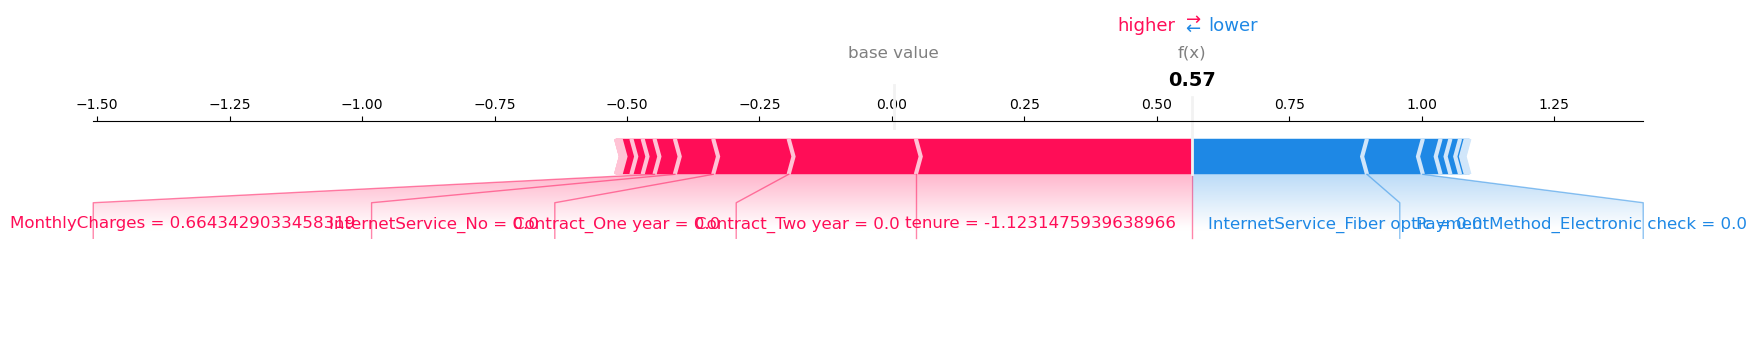

In [53]:
# Cell 50: Test SHAP on new input
explainer = joblib.load('shap_explainer.pkl')

shap_val = explainer.shap_values(processed)

import shap
shap.force_plot(explainer.expected_value, shap_val[0], processed.iloc[0], matplotlib=True)